### SRCNN - Baseline model

<small>

U ovom delu implementiran je **SRCNN** (*Super-Resolution Convolutional Neural Network*) kao **osnovni model** za **rekonstrukciju slika**.

- **LR slike** dimenzija $32×32$ prvo se **BICUBIC interpolacijom** povećavaju na $128×128$ jer **SRCNN** očekuje ulazne slike **iste prostorne dimenzije** kao **ciljna HR slika**.
- **SRCNN** pomoću **tri konvolutivna sloja** uči da iz **BICUBIC**-om povećane slike rekonstruiše detalje koji su izgubljeni prilikom smanjenja rezolucije.
- Model se **trenira** na prethodno formiranim **LR–HR parovima**, pri čemu **HR slike** predstavljaju **ciljne vrednosti**.
- **Performanse modela** procenjene su pomoću **PSNR** i **SSIM metrika**, uz poređenje rezultata **SRCNN**-a sa **BICUBIC interpolacijom**.

</small>

#### I : Učitavanje biblioteka i pripremljenih trening i validacionih skupova

<small>

Učitavaju se prethodno pripremljeni **LR** i **HR podaci** iz $02\_Data\_Preparation.ipynb$ fajla. **LR slike** imaju dimenzije $32×32$, dok **HR slike** imaju dimenzije $128×128$ i predstavljaju **ciljne vrednosti** za treniranje modela.

</small>

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

X_train = np.load("../data/X_train.npy")
y_train = np.load("../data/y_train.npy")

X_val = np.load("../data/X_val.npy")
y_val = np.load("../data/y_val.npy")

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (8000, 32, 32, 3)
y_train: (8000, 128, 128, 3)
X_val: (1000, 32, 32, 3)
y_val: (1000, 128, 128, 3)


<small>

> **Trening skup** sadrži $8.000$ parova, dok **validacioni skup** sadrži $1.000$ parova.<br>
> **LR** slike imaju dimenzije $32×32×3$, a odgovarajuće **HR** slike $128×128×3$, pri čemu $3$ **kanala** predstavljaju **RGB komponente** slike.

</small>

#### II : BICUBIC upsampling

<small>

Pošto **SRCNN** kao **ulaz** koristi sliku koja je prethodno povećana na **ciljnu rezoluciju**, **LR slike** dimenzija $32×32$ se **BICUBIC interpolacijom** povećavaju na $128×128$. Na ovaj način **model** uči da dodatno **poboljša** već **interpoliranu sliku** i **rekonstruiše detalje** originalne **HR slike**.

</small>

In [17]:
def bicubic_upsample(images, target_size=(128, 128)):
    upscaled_images = []

    for img in images:

        img_uint8 = img.astype(np.uint8)

        upscaled = Image.fromarray(img_uint8).resize(target_size, Image.Resampling.BICUBIC)
        upscaled_images.append(np.array(upscaled))

    return np.array(upscaled_images)

X_train_upscaled = bicubic_upsample(X_train)
X_val_upscaled = bicubic_upsample(X_val)

print("X_train upscaled:", X_train_upscaled.shape)
print("X_val upscaled:", X_val_upscaled.shape)

X_train upscaled: (8000, 128, 128, 3)
X_val upscaled: (1000, 128, 128, 3)


<small>

> Nakon **upsamplinga**, sve **LR slike** imaju dimenzije $128×128×3$, čime su **usklađene** sa dimenzijama **HR ciljnih slika**.

</small>

#### III : Normalizacija vrednosti piksela trening i validacionih podataka

<small>

Radi stabilnijeg i efikasnijeg treniranja neuronske mreže, vrednosti piksela **normalizuju** se sa **originalnog intervala** $[0, 255]$ na **interval** $[0, 1]$.

- Ovim postupkom se **vrednosti piksela** svode na **manji** i **ujednačen numerički opseg**, čime se **olakšava proces učenja** i doprinosi **stabilnijem radu modela**.

</small>

In [18]:
X_train_upscaled = X_train_upscaled.astype("float32") / 255.0
y_train = y_train.astype("float32") / 255.0

X_val_upscaled = X_val_upscaled.astype("float32") / 255.0
y_val = y_val.astype("float32") / 255.0

print("X_train min:", X_train_upscaled.min())
print("X_train max:", X_train_upscaled.max())

print("y_train min:", y_train.min())
print("y_train max:", y_train.max())

X_train min: 0.0
X_train max: 1.0
y_train min: 0.0
y_train max: 1.0


<small>

> Nakon normalizacije, **vrednosti piksela** u **trening skupu** za LR i HR slike nalaze se u očekivanom intervalu $[0, 1]$, što potvrđuje da je **normalizacija** uspešno izvršena.

</small>

#### IV : Vizuelna provera BICUBIC upsamplinga

<small>

Nakon **povećanja LR slika**, prikazano je nekoliko **nasumično** odabranih **LR–HR parova** kako bi se vizuelno proverilo kako **BICUBIC interpolacija** utiče na **kvalitet slike**.

- Levo su prikazane **LR slike** nakon **povećanja** na $128×128$, dok su desno odgovarajuće **originalne HR slike** iste dimenzije.<br>
- Ovim poređenjem može se uočiti **razlika u detaljima** između **BICUBIC rekonstrukcije** i **originalne HR slike**.

</small>

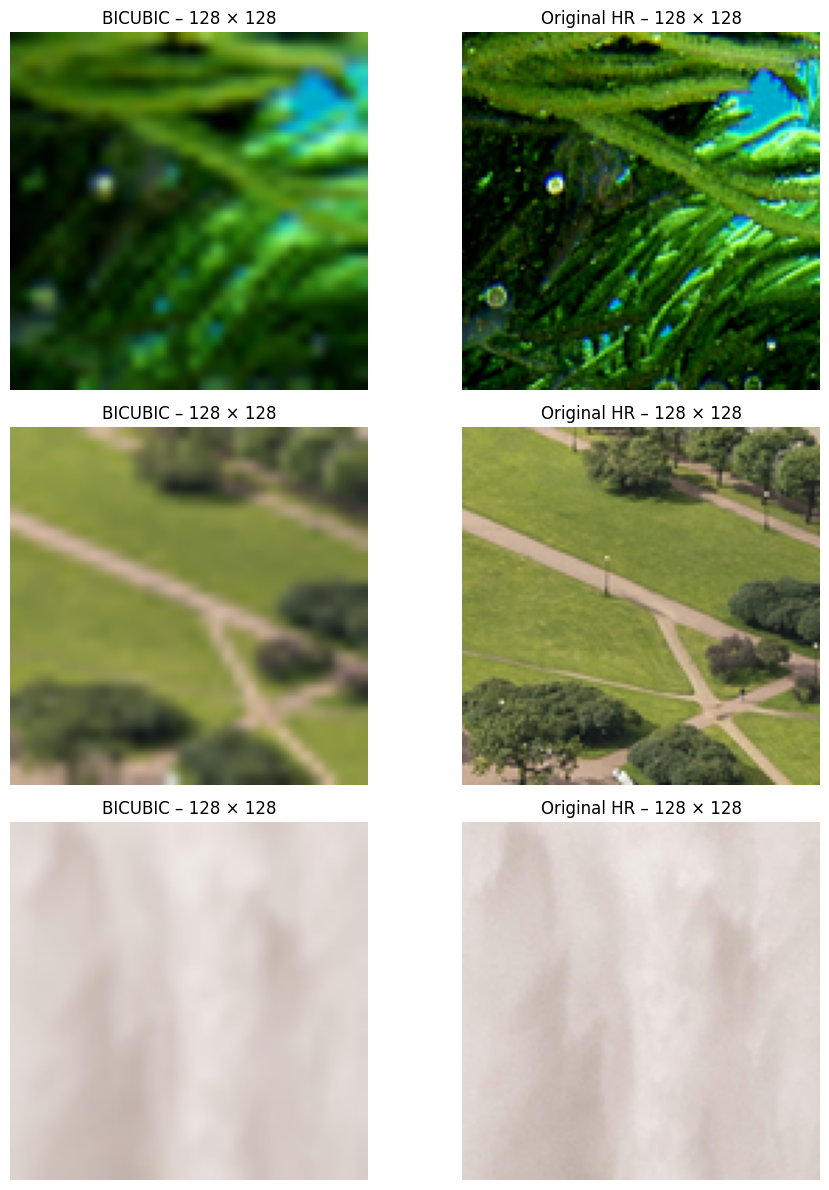

In [19]:
import random

random_indices = random.sample(range(len(X_train_upscaled)), 3)

fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for i, idx in enumerate(random_indices):

    axes[i, 0].imshow(X_train_upscaled[idx])
    axes[i, 0].set_title("BICUBIC – 128 × 128")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(y_train[idx])
    axes[i, 1].set_title("Original HR – 128 × 128")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

<small>

> Vizuelnim poređenjem BICUBIC interpoliranih i originalnih HR slika provereno je da li je proces upsamplinga pravilno izvršen. <br>
>**BICUBIC slike** imaju **istu rezoluciju** kao **HR slike**, ali sadrže **manje detalja**, koje će **SRCNN** pokušati da **rekonstruiše**.

</small>

#### V : Konverzija podataka u tenzore i priprema za treniranje

<small>

Nakon prethodne obrade, podaci se pripremaju za unos u **SRCNN model** implementiran u PyTorch-u.

- **Prilagođavanje formata**: LR i HR slike se **transponuju** iz formata $(H, W, C)$ u $(C, H, W)$, jer PyTorch **konvolutivni slojevi** očekuju da se **broj kanala** nalazi **pre dimenzija slike**.
- **Konverzija u tenzore**: $NumPy$ nizovi se pretvaraju u $torch.Tensor$ objekte kako bi mogli direktno da se koriste u PyTorch modelu.
- **Formiranje skupova**: Odvojeno se formiraju $train_dataset$ i $val_dataset$, koji sadrže **ulazne BICUBIC slike** i odgovarajuće **originalne HR slike**.
- **Batch obrada**: Podaci se organizuju u **batch**-eve od $16$ slika, čime se omogućava **istovremena obrada** više uzoraka tokom treniranja.
- **Mešanje podataka**: Trening podaci se nasumično mešaju ($shuffle=True$) kako bi se **smanjila zavisnost modela** od **redosleda uzoraka**, dok se kod validacionog skupa redosled zadržava ($shuffle=False$) radi konzistentne evaluacije.

</small>

In [20]:
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_upscaled = np.transpose(X_train_upscaled, (0, 3, 1, 2))
y_train = np.transpose(y_train, (0, 3, 1, 2))

X_val_upscaled = np.transpose(X_val_upscaled, (0, 3, 1, 2))
y_val = np.transpose(y_val, (0, 3, 1, 2))

print("X_train_upscaled:", X_train_upscaled.shape)
print("y_train:", y_train.shape)

X_train_tensor = torch.tensor(X_train_upscaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_upscaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

X_train_upscaled: (8000, 3, 128, 128)
y_train: (8000, 3, 128, 128)


<small>

> Nakon transponovanja, **trening podaci** imaju oblik $(8000, 3, 128, 128)$, što odgovara $PyTorch$ formatu (**broj slika**, **broj kanala**, **visina**, **širina**). <br>
> Time su **BICUBIC** i **originalne HR** slike **usklađene po dimenzijama** i spremne za unos u **SRCNN model**.

</small>

#### VI : Arhitektura SRCNN mreže

<small>

U ovom koraku definisana je **SRCNN** (*Super-Resolution Convolutional Neural Network*) mreža koja služi kao **baseline model** za **rekonstrukciju HR slika**.

- Cilj modela je da iz **BICUBIC interpolirane slike** dimenzija $128×128$ nauči da **rekonstruiše detalje** i približi je **originalnoj HR slici**.
- Arhitektura je namerno **jednostavna** i sastoji se od **tri konvolutivna sloja**, što omogućava da se proceni koliko **osnovna CNN arhitektura** može da **poboljša BICUBIC interpolirane slike**.
</small>

<small>

- **Prvi sloj**: $3 → 64$ **filtera** veličine $9×9$ – služi za izdvajanje **osnovnih karakteristika** iz **RGB slike** i koristi **veći kernel** kako bi obuhvatio **širi lokalni deo** slike. <br>
- **Drugi sloj**: $64 → 32$ **filtera** veličine $5×5$ – obrađuje **prethodno izdvojene karakteristike** i uči **složenije obrasce**. Nakon prvog i drugog sloja koristi se **ReLU aktivaciona funkcija**. <br>
- **Treći sloj**: $32 → 3$ **filtera** veličine $5×5$ – **rekonstruiše konačnu RGB sliku**.<br>

</small>

<small>

- **Padding** je podešen tako da se **dimenzije slike** tokom prolaska kroz mrežu **ne menjaju**, pa model na **izlazu** dobija sliku dimenzija $128×128×3$, kao i **ciljna HR slika**.
- Ovakva jednostavna tro-slojna arhitektura izabrana je kao **baseline**, kako bi se dobila početna **procena kvaliteta super-rezolucije** i kasnije omogućilo poređenje sa složenijim modelima.

</small>

In [21]:
import torch.nn as nn
import torch.nn.functional as F

class SRCNN(nn.Module):

    def __init__(self):

        super(SRCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 64, kernel_size=9, padding=4)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=1, padding=0)
        self.conv3 = nn.Conv2d(32, 3, kernel_size=5, padding=2)

    def forward(self, x):

        x = self.conv1(x)
        x = F.relu(x)

        x = self.conv2(x)
        x = F.relu(x)

        x = self.conv3(x)

        return x

model = SRCNN()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

SRCNN(
  (conv1): Conv2d(3, 64, kernel_size=(9, 9), stride=(1, 1), padding=(4, 4))
  (conv2): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
  (conv3): Conv2d(32, 3, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
)

<small>

> Kreirana je instanca **SRCNN modela** i određen je **uređaj za izvršavanje** modela. <br>
> Ukoliko je GPU dostupan, koristiće se CUDA, a u suprotnom model će se izvršavati na CPU-u. 

</small>

In [41]:
def count_parameters(model):

    total_params = sum(p.numel() for p in model.parameters())

    for name, layer in model.named_children():

        num_params = sum(p.numel() for p in layer.parameters())
        print(f"Layer: {name}, parameters: {num_params}")

    return total_params

count_parameters(model)

Layer: conv1, parameters: 15616
Layer: conv2, parameters: 2080
Layer: conv3, parameters: 2403


20099

<small>

> **SRCNN** model sadrži ukupno $20,099$ **parametara** koji se **optimizuju tokom treninga**.<br>
> Najveći broj parametara nalazi se u prvom konvolucionom sloju ($15,616$), dok drugi i treći sloj imaju $2,080$ i $2,403$ parametra. <br>
> Relativno **mali ukupan broj parametara** ukazuje na **jednostavnu*** i **računarski efikasnu arhitekturu**, pogodnu za korišćenje kao **početni model** za **super-rezoluciju**.

</small>

#### VII : Treniranje SRCNN modela

<small>

- Kao funkcija gubitka (*loss*) korišćena je **srednja kvadratna greška** (*MSE*) između predviđene i ciljne (visoko-rezolucijske) slike, jer direktno penalizuje **odstupanje intenziteta piksela** i standardna je funkcija gubitka za regresione probleme rekonstrukcije slika poput super-rezolucije.
- Uporedo sa **MSE**, tokom treninga je praćena i **srednja apsolutna greška** (*MAE*) kao dodatna, robusnija metrika koja **manje penalizuje ekstremna odstupanja** (*outliere*) i daje dodatni uvid u ponašanje modela.

</small>

In [25]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import copy

optimizer = optim.Adam(model.parameters(), lr=1e-4)
n_epochs = 100

metrics = {'train_mse': [], 'train_mae': [], 'train_step': [], 'val_mse': [], 'val_mae': [], 'val_step': []}
training_step = 0

best_val_loss = float("inf")
best_model_state = None
counter = 0
patience = 10

for epoch in range(n_epochs):

    model.train()

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        y_pred = model(x_batch)

        mse = F.mse_loss(y_pred, y_batch)
        mae = torch.abs(y_pred - y_batch).mean()

        metrics['train_mse'].append(mse.item())
        metrics['train_mae'].append(mae.item())
        metrics['train_step'].append(training_step)
        training_step += 1

        optimizer.zero_grad()
        mse.backward()
        optimizer.step()

    model.eval()

    val_mse_sum = 0.0
    val_mae_sum = 0.0
    val_samples = 0


    with torch.no_grad():

        for x_batch, y_batch in val_loader:

            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(x_batch)

            val_mse_sum += F.mse_loss(y_pred, y_batch, reduction='sum').item()
            val_mae_sum += torch.abs(y_pred - y_batch).sum().item()
            val_samples += y_batch.numel()

    val_mse = val_mse_sum / val_samples
    val_mae = val_mae_sum / val_samples

    metrics['val_mse'].append(val_mse)
    metrics['val_mae'].append(val_mae)
    metrics['val_step'].append(training_step)


    print(f"Epoch {epoch+1}/{n_epochs}, "f"Train MSE: {metrics['train_mse'][-1]:.6f}, "f"Train MAE: {metrics['train_mae'][-1]:.6f}, "f"Val MSE: {val_mse:.6f}, "f"Val MAE: {val_mae:.6f}")

    if val_mse + 1e-5 < best_val_loss:
        best_val_loss = val_mse
        best_model_state = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("EARLY STOPPING!")
            break

Epoch 1/100, Train MSE: 0.004201, Train MAE: 0.038507, Val MSE: 0.003959, Val MAE: 0.036612
Epoch 2/100, Train MSE: 0.003774, Train MAE: 0.032533, Val MSE: 0.003433, Val MAE: 0.032593
Epoch 3/100, Train MSE: 0.003149, Train MAE: 0.033577, Val MSE: 0.003296, Val MAE: 0.031628
Epoch 4/100, Train MSE: 0.003336, Train MAE: 0.032590, Val MSE: 0.003210, Val MAE: 0.031005
Epoch 5/100, Train MSE: 0.003443, Train MAE: 0.032191, Val MSE: 0.003154, Val MAE: 0.030518
Epoch 6/100, Train MSE: 0.003669, Train MAE: 0.030141, Val MSE: 0.003139, Val MAE: 0.031017
Epoch 7/100, Train MSE: 0.001227, Train MAE: 0.015990, Val MSE: 0.003095, Val MAE: 0.030190
Epoch 8/100, Train MSE: 0.004355, Train MAE: 0.032765, Val MSE: 0.003088, Val MAE: 0.030491
Epoch 9/100, Train MSE: 0.002603, Train MAE: 0.023928, Val MSE: 0.003058, Val MAE: 0.029985
Epoch 10/100, Train MSE: 0.003923, Train MAE: 0.036239, Val MSE: 0.003033, Val MAE: 0.029696
Epoch 11/100, Train MSE: 0.002209, Train MAE: 0.026331, Val MSE: 0.003021, Val 

<small>

> **Val MSE** se smanjuje sa $0.003959$ na oko $0.002830$ → model uči. <br>
> **Val MSE** ne pokazuje jasan trend rasta, pa **nema jasnih znakova overfittinga**; za pouzdaniji zaključak trebalo bi uporediti **prosečan Train MSE** i **Val MSE** po **epohama**. 

> Tokom treninga, MSE i MAE greške na **trening skupu** beležene su nakon svakog **batch**-a, čime je omogućeno detaljno praćenje promene greške kroz pojedinačne korake optimizacije ($training steps$).
> Nasuprot tome, **validacione metrike** računane su nakon svake **epohe** nad celim validacionim skupom. 
> Zbog toga pojedinačne vrednosti trening greške mogu oscilovati između batch-eva, dok **validacione metrike** daju **stabilniju procenu performansi** modela nakon svake epohe.

</small>

<small>

Tokom treniranja pratimo vrednosti **MSE** i **MAE grešaka** na **trening** i **validacionom skupu** kako bismo analizirali **proces učenja** modela. 

- **Trening metrike** beleže se nakon svakog **batch**-a, dok se **validacione metrike** računaju nakon svake epohe nad celim validacionim skupom.
-  Na ovaj način možemo pratiti **konvergenciju** modela, uočiti **stabilizaciju greške** i potencijalne **znake overfitting-a**.

</small>

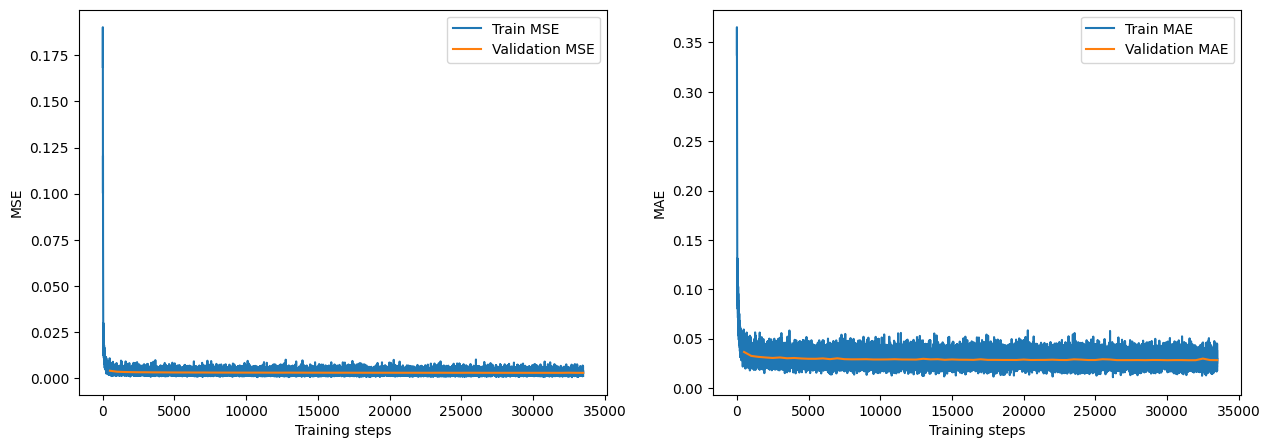

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.plot(metrics['train_step'], metrics['train_mse'], label = 'Train MSE')
plt.plot(metrics['val_step'],metrics['val_mse'], label = 'Validation MSE')
plt.xlabel("Training steps")
plt.ylabel("MSE")
plt.legend()

plt.subplot(1,2,2)
plt.plot(metrics['train_step'], metrics['train_mae'], label = 'Train MAE')
plt.plot(metrics['val_step'],metrics['val_mae'], label = 'Validation MAE')
plt.xlabel("Training steps")
plt.ylabel("MAE")
plt.legend()

plt.show()

<small>

> Na početku treninga uočava se nagli **pad MSE i MAE grešaka**, što ukazuje na **brzo početno učenje** modela. <br>
> Nakon toga dolazi do postepene **stabilizacije** metrika, pri čemu **validacione greške** ne pokazuju trend rasta, odnosno **nema jasnih znakova** izraženog **overfittinga**. <br>
> **Veće oscilacije trening metrika*** posledica su njihovog računanja na nivou pojedinačnih **batch**-eva, dok se **validacione metrike** računaju nad **celim validacionim skupom**.

</small>

#### VIII : Evaluacija SRCNN modela na validacionom skupu

<small>

Nakon završetka treninga učitava se **najbolja verzija SRCNN modela**, odabrana na osnovu **minimalne MSE greške** na **validacionom **skupu**.

- Performanse modela analiziraju se pomoću **PSNR** i **SSIM** metrika, a rezultati se **porede** sa **Bicubic interpolacijom**, koja predstavlja **referentni metod**.
- **PSNR** (*Peak Signal-to-Noise Ratio*) meri **razliku između vrednosti piksela** rekonstruisane i originalne HR slike. Zasniva se na **MSE grešci** i izražava se u **decibelima** ($dB$). **Veća vrednost PSNR**-a ukazuje na **manju grešku** i **bolji kvalitet rekonstrukcije**.
- **SSIM** (*Structural Similarity Index*) meri **strukturnu sličnost** rekonstruisane i originalne HR slike, uzimajući u obzir osvetljenost, kontrast i strukturu. Vrednosti **bliže 1** ukazuju na **veću sličnost** sa originalnom HR slikom.
- Za svaku sliku **validacionog skupa** sa originalnom HR slikom porede se **Bicubic rekonstrukcija** i **izlaz SRCNN modela**.
- **PSNR** i **SSIM** računaju se **pojedinačno** za svaku sliku, nakon čega se posmatraju njihove **prosečne vrednosti** na validacionom skupu.

Cilj ove evaluacije je da se na **validacionom skupu** utvrdi da li **primena SRCNN modela** dovodi do **poboljšanja kvaliteta rekonstrukcije** u odnosu na početnu **Bicubic interpolaciju**, odnosno **slučaj bez primene modela**.


</small>

In [37]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import pandas as pd

model.load_state_dict(best_model_state)

X_val_eval = []
predictions = []
y_val_eval = []

psnr_bicubic = []
ssim_bicubic = []

psnr_srcnn = []
ssim_srcnn = []

model.eval()

with torch.no_grad():

    for x_batch, y_batch in val_loader:

        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred = model(x_batch)
        y_pred = torch.clamp(y_pred, 0, 1) # ograničimo vrednosti piksela na [0, 1]

        x_batch = x_batch.cpu().numpy() # tenzori, a skimage.metrics ocekuje NumPy nizove
        y_pred = y_pred.cpu().numpy()
        y_batch = y_batch.cpu().numpy()

        X_val_eval.append(x_batch)
        predictions.append(y_pred)
        y_val_eval.append(y_batch)

        for bicubic, pred, true in zip(x_batch, y_pred, y_batch):

            # (C, H, W) -> (H, W, C)
            bicubic = np.transpose(bicubic, (1, 2, 0)) # skimage za RGB sliku očekuje (H, W, C)
            pred = np.transpose(pred, (1, 2, 0)) 
            true = np.transpose(true, (1, 2, 0))

            psnr_bicubic.append(psnr(true, bicubic, data_range=1.0))
            ssim_bicubic.append(ssim(true, bicubic, data_range=1.0, channel_axis=-1))

            psnr_srcnn.append(psnr(true, pred, data_range=1.0))
            ssim_srcnn.append(ssim(true, pred, data_range=1.0, channel_axis=-1)) # RGB kanali se nalaze na poslednjoj dimenziji

X_val_eval = np.concatenate(X_val_eval, axis=0)
predictions = np.concatenate(predictions, axis=0)
y_val_eval = np.concatenate(y_val_eval, axis=0)

# (N, C, H, W) -> (N, H, W, C)
X_val_eval = X_val_eval.transpose(0, 2, 3, 1)
predictions = predictions.transpose(0, 2, 3, 1)
y_val_eval = y_val_eval.transpose(0, 2, 3, 1)

psnr_bicubic_array = np.array(psnr_bicubic)
psnr_srcnn_array = np.array(psnr_srcnn)
ssim_bicubic_array = np.array(ssim_bicubic)
ssim_srcnn_array = np.array(ssim_srcnn)

perfect_indices = np.where(np.isinf(psnr_bicubic_array))[0] # Indeksi na kojima Bicubic ima PSNR = inf

mask = ~np.isinf(psnr_bicubic_array)

psnr_bicubic_filtered = psnr_bicubic_array[mask]
psnr_srcnn_filtered = psnr_srcnn_array[mask]
ssim_bicubic_filtered = ssim_bicubic_array[mask]
ssim_srcnn_filtered = ssim_srcnn_array[mask]

results = pd.DataFrame({
    "Method": ["Bicubic", "SRCNN"],
    "PSNR - all images": [np.mean(psnr_bicubic_array), np.mean(psnr_srcnn_array)],
    "SSIM - all images": [np.mean(ssim_bicubic_array), np.mean(ssim_srcnn_array)],
    "PSNR - filtered": [np.mean(psnr_bicubic_filtered), np.mean(psnr_srcnn_filtered)],
    "SSIM - filtered": [np.mean(ssim_bicubic_filtered), np.mean(ssim_srcnn_filtered)]
})

results


C:\Users\T590\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\skimage\metrics\simple_metrics.py:171: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


,Method,PSNR - all images,SSIM - all images,PSNR - filtered,SSIM - filtered
0,Bicubic,inf,0.763039,30.046868,0.761608
1,SRCNN,30.220795,0.788144,30.102128,0.786882


<small>

> Kod **Bicubic metode** na svih 1000 slika **nije moguće** dobiti **konačan prosečan PSNR** (inf), jer postoji $6$ **savršenih rekonstrukcija** kod kojih je $MSE = 0$, a samim tim $PSNR = ∞$. <br>
> Nakon **uklanjanja** istih $6$ slika iz **oba metoda**, **Bicubic** ostvaruje $PSNR = 30.0469 dB$, dok **SRCNN** ostvaruje $PSNR = 30.1021 dB$.<br>
> **SRCNN** ostvaruje **blago poboljšanje PSNR**-a od oko $0.055 dB$, što znači da je **razlika u pikselnoj grešci** u odnosu na **Bicubic** veoma **mala**.

> Na istom skupu slika **Bicubic** ostvaruje $SSIM = 0.7616$, dok **SRCNN** ostvaruje $SSIM = 0.7869$.<br>
> Poboljšanje **SSIM**-a od oko $0.0253$ **izraženije** je od poboljšanja **PSNR**-a, što ukazuje da **SRCNN** pre svega doprinosi **boljem očuvanju strukture** i **vizuelnih karakteristika slike**.

> **SRCNN** jeste uspeo da nadmaši **baseline** po **obe metrike**, ali je dobitak u **PSNR**-u mali, dok **SSIM** pokazuje **jasnije poboljšanje strukture slike**.

</small>

<small>

Posmatramo slike kod kojih je **poboljšanje** nakon primene **SRCNN** modela **najuočljivije**. 

- U tu svrhu izdvajamo **primere** sa **najvećim porastom SSIM** vrednosti u odnosu na **Bicubic interpolaciju**. 
- Njihovim vizuelnim **poređenjem** sa **originalnim HR slikama** možemo jasnije uočiti na koji način **SRCNN** **unapređuje kvalitet rekonstrukcije** i koje detalje i strukture uspeva bolje da očuva.

</small>

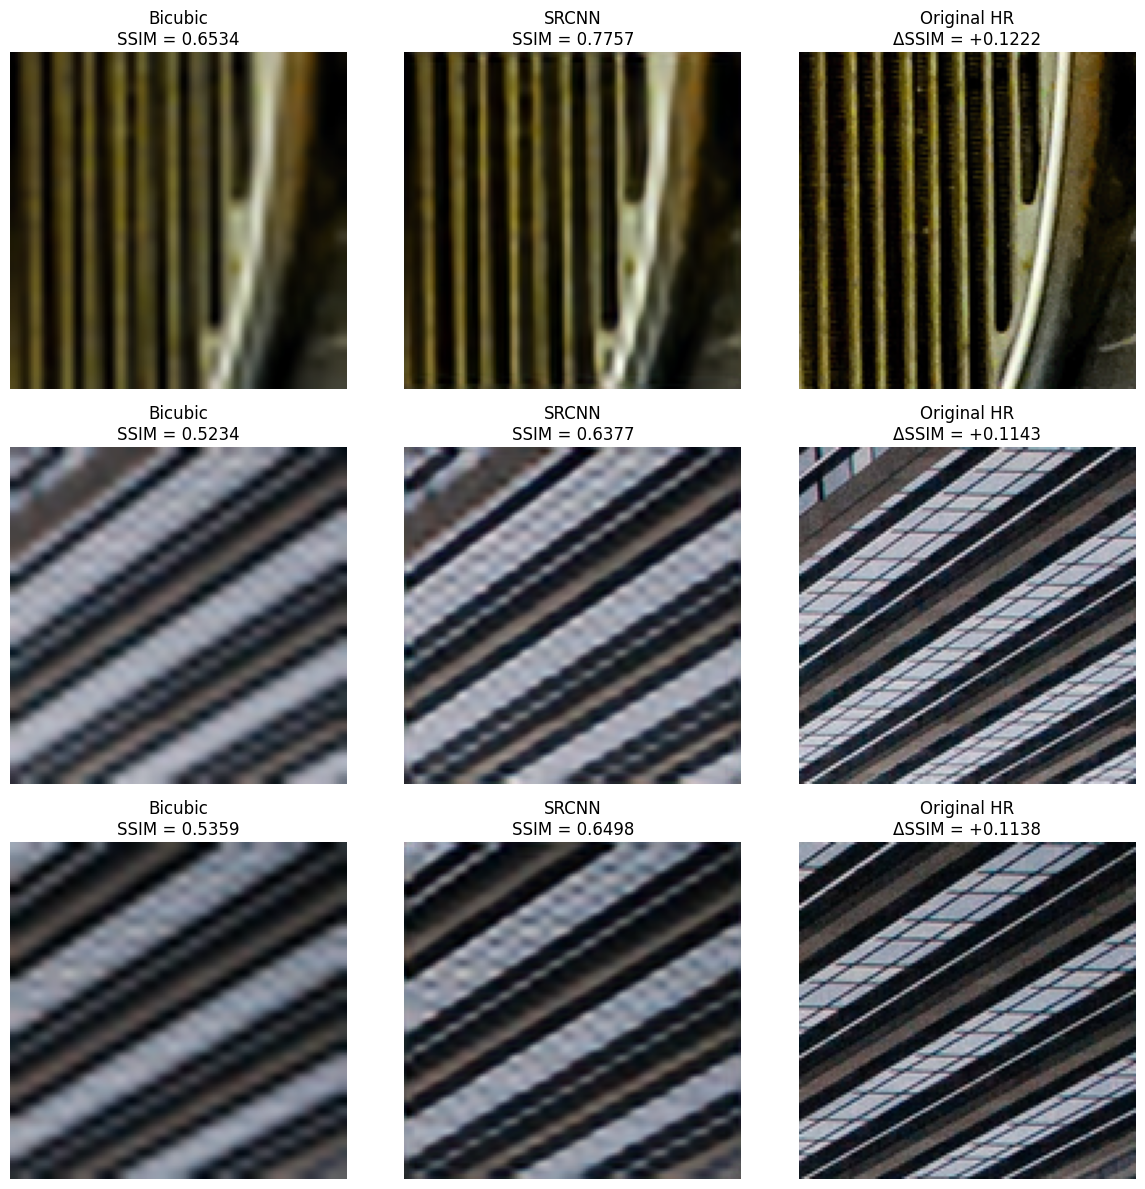

In [40]:
# Razlika između SRCNN i Bicubic SSIM-a za svaku sliku
ssim_improvement = np.array(ssim_srcnn) - np.array(ssim_bicubic)

# Indeksi 3 slike sa najvećim poboljšanjem SSIM-a
best_indices = np.argsort(ssim_improvement)[-3:][::-1]

fig, axes = plt.subplots(3, 3, figsize=(12, 12))


for i, idx in enumerate(best_indices):

    # Bicubic
    axes[i, 0].imshow(X_val_eval[idx])
    axes[i, 0].set_title(f"Bicubic\nSSIM = {ssim_bicubic[idx]:.4f}")
    axes[i, 0].axis("off")

    # SRCNN
    axes[i, 1].imshow(predictions[idx])
    axes[i, 1].set_title(f"SRCNN\nSSIM = {ssim_srcnn[idx]:.4f}")
    axes[i, 1].axis("off")

    # Original HR
    axes[i, 2].imshow(y_val_eval[idx])
    axes[i, 2].set_title(f"Original HR\nΔSSIM = {ssim_improvement[idx]:+.4f}")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

<small>

> Kod sva tri prikazana primera **SRCNN** ostvaruje **značajno viši SSIM** u odnosu na **Bicubic interpolaciju**, sa poboljšanjem od približno $0.11–0.12$.
> Vizuelno se uočava da su **Bicubic rekonstrukcije** **zamućenije**, dok **SRCNN** daje **oštrije** i **jasnije definisane ivice i linije**.
> **Poboljšanje** je posebno **izraženo** kod **pravilnih** i **ponavljajućih struktura**, kao što su **paralelne linije** prikazane na slikama.

> Rezultati pokazuju da **SRCNN** ne vraća u potpunosti izgubljene fine detalje, ali uspeva da **ublaži zamućenje** nastalo **interpolacijom **i **bolje rekonstruiše** izražene **ivice** i **obrasce**.

</small>

<small>

Dobijeni rezultati predstavljaju **zadovoljavajuću početnu tačku**, s obzirom na to da **osnovni SRCNN** model nadmašuje **Bicubic interpolaciju** prema **obe** posmatrane **metrike**. 

- Iako je **poboljšanje PSNR-a malo**, izraženije **povećanje SSIM-a** ukazuje na **potencijal modela** za **bolje očuvanje strukturnih karakteristika slike**.
- Dobijeni rezultati će služiti kao **referentne vrednosti** za **poređenje** sa narednim, **unapređenim modelima**.

</small>